In [1]:
import cv2
import os
import matplotlib.pyplot as plt

In [2]:
input_folder = r"C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\denoised_frames\match1"
output_folder = r"C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\enhanced_frames\match1"

os.makedirs(output_folder, exist_ok=True)

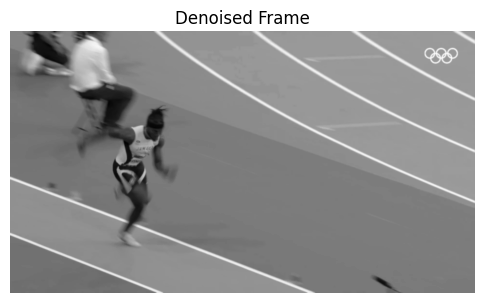

In [3]:
frame_name = "frame_0000.jpg"

input_path = os.path.join(input_folder, frame_name)
img = cv2.imread(input_path, 0)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title("Denoised Frame")
plt.axis("off")
plt.show()

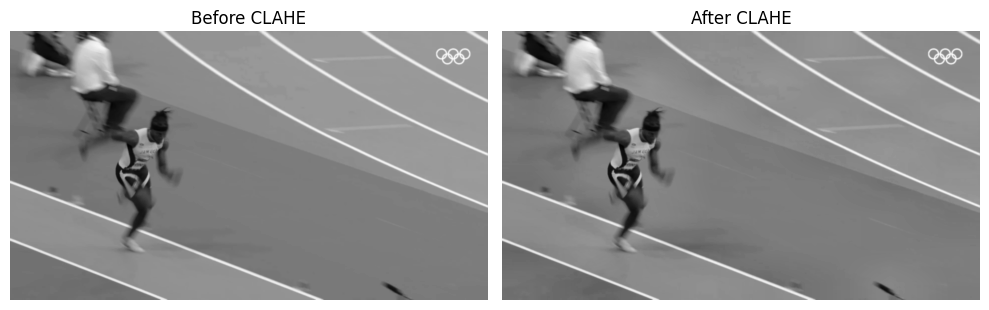

In [4]:
clahe = cv2.createCLAHE(clipLimit=0.3, tileGridSize=(8,8))
clahe_img = clahe.apply(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Before CLAHE")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(clahe_img, cmap="gray")
plt.title("After CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

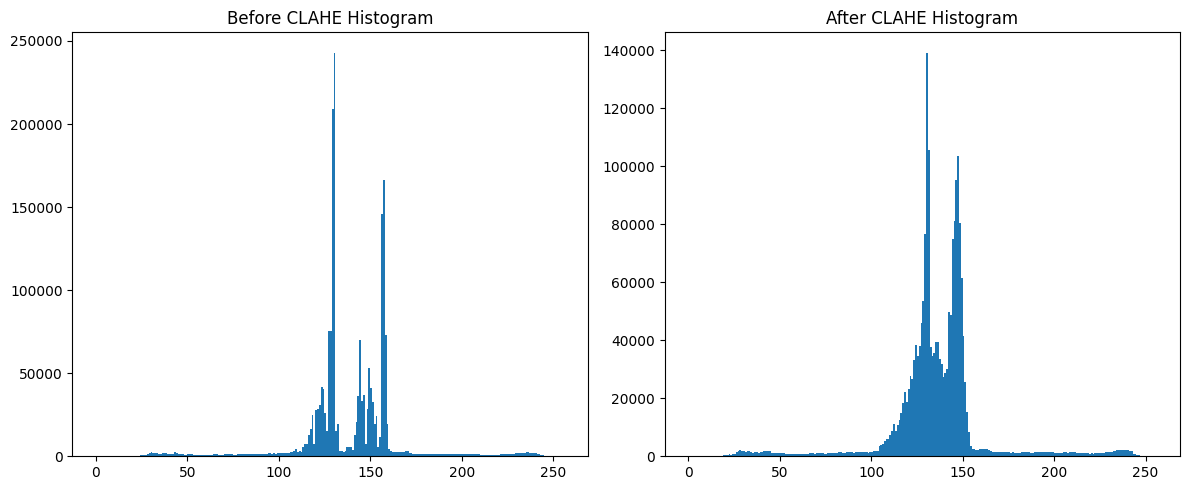

In [5]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(img.ravel(), bins=256, range=(0,256))
plt.title("Before CLAHE Histogram")

plt.subplot(1,2,2)
plt.hist(clahe_img.ravel(), bins=256, range=(0,256))
plt.title("After CLAHE Histogram")

plt.tight_layout()
plt.show()

In [6]:
frame_files = sorted(os.listdir(input_folder))

clahe = cv2.createCLAHE(clipLimit=0.3, tileGridSize=(8,8))

for file in frame_files:
    if file.endswith(".jpg") or file.endswith(".png") or file.endswith(".jpeg"):
        path = os.path.join(input_folder, file)
        img = cv2.imread(path, 0)

        enhanced = clahe.apply(img)

        save_path = os.path.join(output_folder, file)
        cv2.imwrite(save_path, enhanced)

print("CLAHE enhanced frames saved successfully.")

CLAHE enhanced frames saved successfully.


In [7]:
import time
import numpy as np

processing_times = []

frame_files = sorted(os.listdir(input_folder))
clahe = cv2.createCLAHE(clipLimit=0.3, tileGridSize=(8,8))

for file in frame_files:
    if file.endswith(".jpg") or file.endswith(".png") or file.endswith(".jpeg"):
        
        start_time = time.time()
        
        input_path = os.path.join(input_folder, file)
        img = cv2.imread(input_path, 0)
        
        enhanced = clahe.apply(img)
        
        end_time = time.time()
        
        processing_time = end_time - start_time
        processing_times.append(processing_time)

average_time = np.mean(processing_times)

print("Enhancement Pipeline Processing Time")
print("Total Frames Processed:", len(processing_times))
print("Average Processing Time per Frame:", round(average_time, 5), "seconds")
print("Minimum Processing Time:", round(min(processing_times), 5), "seconds")
print("Maximum Processing Time:", round(max(processing_times), 5), "seconds")

Enhancement Pipeline Processing Time
Total Frames Processed: 164
Average Processing Time per Frame: 0.02141 seconds
Minimum Processing Time: 0.018 seconds
Maximum Processing Time: 0.029 seconds
